Phase 3: Cleaning the Data

In [1]:
import pandas as pd
df = pd.read_csv("driver_season_data.csv", encoding="latin1")
df

,S.No,driver_name,season,series,total_points,wins,podiums,final_rank,age,f1_progression,f1_entry_year,pole_position,total_races,dnfs,points_per_race,win_rate,podium_rate,dnf_rate,season_weight
0,1,N. de Vries,2019,F2,266.0,4,12,1,24,1,2023.0,5,22,0,12.091,0.182,0.545,0.000,1.000000
1,2,N. Latifi,2019,F2,214.0,4,8,2,24,0,NaN,0,22,0,9.727,0.182,0.364,0.000,1.000000
2,3,L. Ghiotto,2019,F2,207.0,4,9,3,24,0,NaN,2,22,3,9.409,0.182,0.409,0.136,1.000000
3,4,S. Sette Câmara,2019,F2,204.0,2,8,4,21,0,NaN,2,22,2,9.273,0.091,0.364,0.091,1.000000
4,5,J. Aitken,2019,F2,159.0,3,7,5,24,0,NaN,0,22,1,7.227,0.136,0.318,0.045,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
448,449,N. Johnson,2025,F3,0.0,0,0,33,17,0,NaN,0,16,4,0.000,0.000,0.000,0.250,6.049647
449,450,J. Sagrera,2025,F3,0.0,0,0,34,21,0,NaN,0,14,3,0.000,0.000,0.000,0.214,6.049647
450,451,F. Barrichello,2025,F3,0.0,0,0,35,20,0,NaN,0,6,1,0.000,0.000,0.000,0.167,6.049647
451,452,N. Marinangeli,2025,F3,0.0,0,0,36,21,0,NaN,0,4,2,0.000,0.000,0.000,0.500,6.049647


In [2]:
df.columns = df.columns.str.strip().str.lower()

In [3]:
# checking the data for missing value or wrong data type
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 453 entries, 0 to 452
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   s.no             453 non-null    int64  
 1   driver_name      453 non-null    object 
 2   season           453 non-null    int64  
 3   series           453 non-null    object 
 4   total_points     453 non-null    float64
 5   wins             453 non-null    int64  
 6   podiums          453 non-null    int64  
 7   final_rank       453 non-null    int64  
 8   age              453 non-null    int64  
 9   f1_progression   453 non-null    int64  
 10  f1_entry_year    38 non-null     float64
 11  pole_position    453 non-null    int64  
 12  total_races      453 non-null    int64  
 13  dnfs             453 non-null    int64  
 14  points_per_race  453 non-null    float64
 15  win_rate         453 non-null    float64
 16  podium_rate      453 non-null    float64
 17  dnf_rate        

s.no                 0
driver_name          0
season               0
series               0
total_points         0
wins                 0
podiums              0
final_rank           0
age                  0
f1_progression       0
f1_entry_year      415
pole_position        0
total_races          0
dnfs                 0
points_per_race      0
win_rate             0
podium_rate          0
dnf_rate             0
season_weight        0
dtype: int64

In [4]:
# Handling the missing value and Removing the Duplicates
df = df.drop_duplicates()

In [5]:
df = df[(df['f1_entry_year'].isna()) |
        (df['season'] < df['f1_entry_year'])]

In [6]:
# Logical consistency test for checking every driver win
#                     is less thean the total number of races.
(df['wins'] > df['total_races']).sum()
(df['dnfs'] > df['total_races']).sum()

np.int64(0)

In [7]:
# Target Variable -
#        Drivers who qualified to F1 v/s other drivers.
df['f1_progression'].value_counts()

f1_progression
0    415
1     38
Name: count, dtype: int64

In [8]:
df[['season','season_weight']].drop_duplicates().sort_values('season')

,season,season_weight
0,2019,1.000000
61,2020,1.349859
122,2021,1.822119
186,2022,2.459603
255,2023,3.320117
315,2024,4.481689
380,2025,6.049647


In [9]:
df['w_points_per_race'] = df['points_per_race'] * df['season_weight']
df['w_pole_position'] = df['pole_position'] * df['season_weight']

In [10]:
df.to_csv("clean_driver_data_weighted.csv", index=False)

Phase 4: Exploratory Data Analysis (EDA)

In [11]:
# Descriptive Statistics
df.describe()

,s.no,season,total_points,wins,podiums,final_rank,age,f1_progression,f1_entry_year,pole_position,total_races,dnfs,points_per_race,win_rate,podium_rate,dnf_rate,season_weight,w_points_per_race,w_pole_position
count,453.000000,453.000000,453.000000,453.000000,453.000000,453.000000,453.000000,453.000000,38.000000,453.000000,453.000000,453.000000,453.000000,453.000000,453.000000,453.000000,453.000000,453.000000,453.000000
mean,227.000000,2022.088300,51.916115,0.668874,1.982340,17.024283,20.549669,0.083885,2023.552632,0.335541,17.229581,2.090508,2.489066,0.031060,0.094060,0.122664,3.006205,7.083105,0.939212
std,130.914094,2.012389,60.768317,1.121325,2.594181,9.850063,2.412235,0.277522,1.639007,0.807868,7.615210,1.632963,2.772654,0.051853,0.120301,0.100518,1.726167,8.857041,2.552367
min,1.000000,2019.000000,0.000000,0.000000,0.000000,1.000000,16.000000,0.000000,2021.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,114.000000,2020.000000,0.000000,0.000000,0.000000,9.000000,19.000000,0.000000,2023.000000,0.000000,16.000000,1.000000,0.000000,0.000000,0.000000,0.056000,1.349859,0.000000,0.000000
50%,227.000000,2022.000000,25.000000,0.000000,1.000000,17.000000,20.000000,0.000000,2023.000000,0.000000,18.000000,2.000000,1.450000,0.000000,0.050000,0.111000,2.459603,3.795473,0.000000
75%,340.000000,2024.000000,93.000000,1.000000,4.000000,25.000000,22.000000,0.000000,2025.000000,0.000000,22.000000,3.000000,4.200000,0.050000,0.167000,0.167000,4.481689,11.204223,0.000000
max,453.000000,2025.000000,266.000000,6.000000,12.000000,40.000000,31.000000,1.000000,2026.000000,5.000000,28.000000,9.000000,13.250000,0.261000,0.625000,0.500000,6.049647,50.212074,30.248237


In [12]:
# Comparing the groups w.r.t. 
#           driver who qualified to F1 v/s other drivers.
df.groupby('f1_progression').mean(numeric_only=True)

,s.no,season,total_points,wins,podiums,final_rank,age,f1_entry_year,pole_position,total_races,dnfs,points_per_race,win_rate,podium_rate,dnf_rate,season_weight,w_points_per_race,w_pole_position
f1_progression,,,,,,,,,,,,,,,,,,
0,233.501205,2022.168675,45.622892,0.551807,1.715663,17.857831,20.640964,NaN,0.257831,16.93012,2.067470,2.214133,0.025952,0.082292,0.122795,3.081089,6.638662,0.783771
1,156.000000,2021.210526,120.644737,1.947368,4.894737,7.921053,19.552632,2023.552632,1.184211,20.50000,2.342105,5.491632,0.086842,0.222579,0.121237,2.188389,11.936901,2.636790


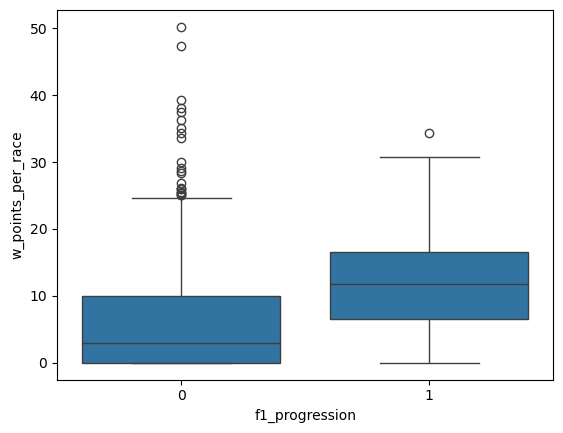

In [13]:
# BOXPLOT
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='f1_progression', y='w_points_per_race', data=df)
plt.show()

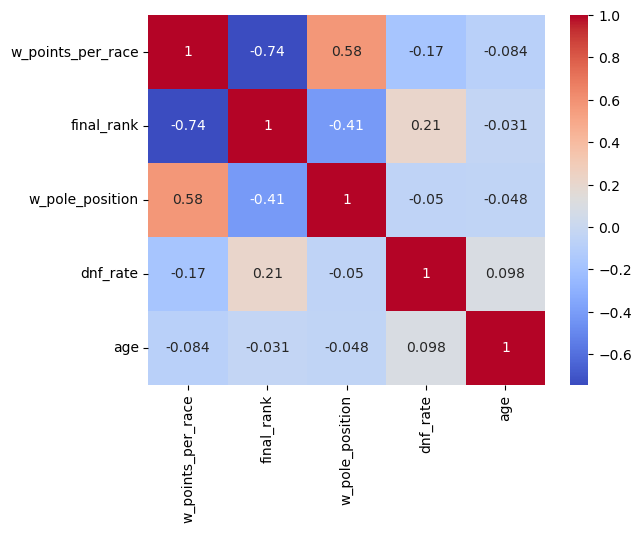

In [14]:
# Correlation Matrix to check for very high  correlations (>0.8)
#         to remove reduntant ones before regression.
corr = df[['w_points_per_race','final_rank','w_pole_position','dnf_rate','age']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

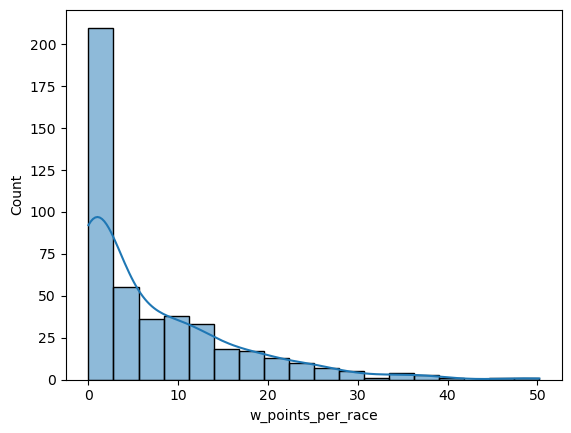

In [15]:
# Checking distribution for skewness or outliers with Histogram
sns.histplot(df['w_points_per_race'], kde=True)
plt.show()

In [16]:
df[['season','season_weight']].drop_duplicates().sort_values('season')

,season,season_weight
0,2019,1.000000
61,2020,1.349859
122,2021,1.822119
186,2022,2.459603
255,2023,3.320117
315,2024,4.481689
380,2025,6.049647


Phase 5: Hypothesis Testing

In [17]:
# H0: There is no significant difference between progressed and non-progressed drivers
# H1: There is significant difference between progressed and non-progressed drivers

In [18]:
#Spliting the Data to progressed and non_progressed 
progressed = df[df['f1_progression'] == 1]
not_progressed = df[df['f1_progression'] == 0]

In [19]:
# Performing independent T-test to compare the p-values
from scipy.stats import ttest_ind

variables = [
    'w_points_per_race',
    'final_rank',
    'w_pole_position',
    'dnf_rate',
    'age'
]

for var in variables:
    stat, p = ttest_ind(progressed[var],
                        not_progressed[var],
                        equal_var=False)
    if p<0.05:
        print(f"{var}: p-value = {p}, Significant")
    else:
        print(f"{var}: p-value = {p}, Not Significant")

w_points_per_race: p-value = 0.0007070486817950092, Significant
final_rank: p-value = 7.459764557012985e-10, Significant
w_pole_position: p-value = 0.0011912325137642882, Significant
dnf_rate: p-value = 0.9245469931179119, Not Significant
age: p-value = 0.00015872316395764376, Significant


In [20]:
#Final Interpretation for Hypothesis Testing
#Points_per_race: There is a significant difference between progressed 
#                                                     and non_progressed drivers.
#Win_rate: There is a significant difference between progressed 
#                                                     and non_progressed drivers.
#Podium_rate: There is a significant difference between progressed 
#                                                     and non_progressed drivers.
#Final_rank: There is a significant difference between progressed
#                                                     and non_progressed drivers.
#Dnf_rate: There is a no significant difference between progressed 
#                                                     and non_progressed drivers.
#Age: There is a significant difference between progressed and non_progressed drivers.

Phase 6: Logistics Regression

Full Model

In [21]:
# Not selecting total__points, wins, and podiums as it creates multicollinearity.
# Defining X and Y Variables
X = df[['w_points_per_race',
        'final_rank',
        'w_pole_position',
        'dnf_rate',
        'age']]

y = df['f1_progression']

In [22]:
# Spliting the data into Train-Test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [23]:
# As logistic regression performs better when variables are scaled
#                            hence standardizing the features.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
# Fitting Logistics Regression Model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [25]:
# Prediction
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [26]:
# Accuracy of the model
from sklearn.metrics import accuracy_score
log_accuracy=accuracy_score(y_test, y_pred)
log_accuracy

0.9191176470588235

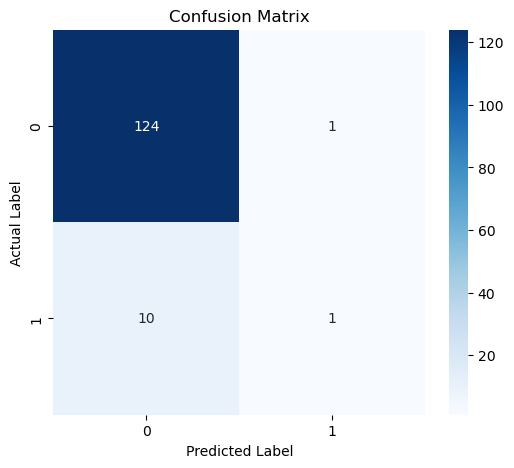

In [27]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

In [28]:
# Classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96       125
           1       0.50      0.09      0.15        11

    accuracy                           0.92       136
   macro avg       0.71      0.54      0.56       136
weighted avg       0.89      0.92      0.89       136



In [29]:
# ROC-AUC Score 
from sklearn.metrics import roc_auc_score
log_auc=roc_auc_score(y_test, y_prob)
log_auc

np.float64(0.8974545454545455)

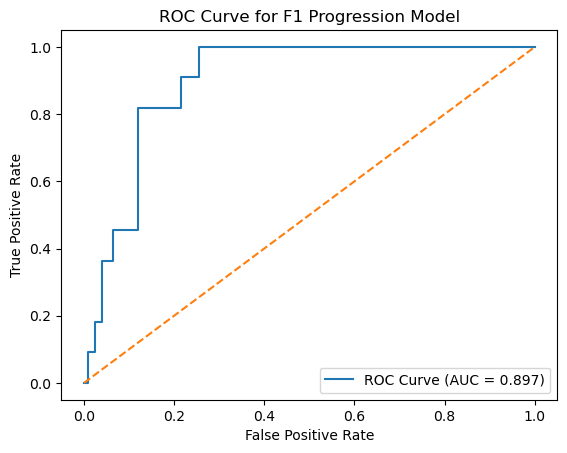

In [30]:
#ROC Curve
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label='ROC Curve (AUC = 0.897)')
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for F1 Progression Model")
plt.legend()
plt.show()

In [31]:
# Interpreting Coefficient
import pandas as pd

coefficients = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': model.coef_[0]
})

coefficients

,Variable,Coefficient
0,w_points_per_race,-0.661140
1,final_rank,-1.583740
2,w_pole_position,0.426977
3,dnf_rate,0.548820
4,age,-0.538672


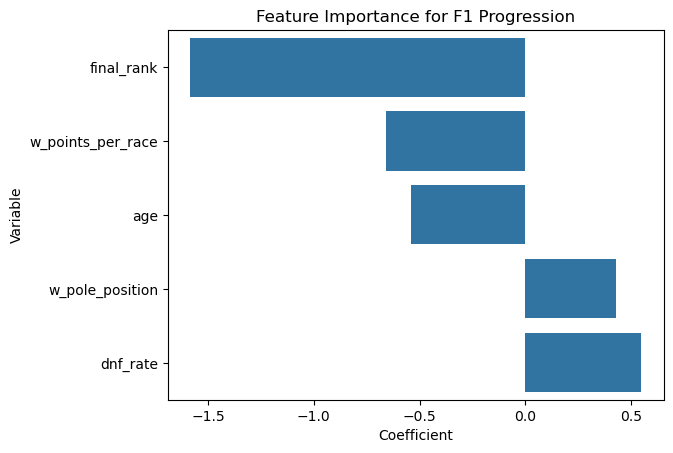

In [32]:
#Feature Importance for F1 Progression
import pandas as pd
import seaborn as sns

coef_df = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_[0]
})

coef_df = coef_df.sort_values(by="Coefficient")

plt.figure()
sns.barplot(x="Coefficient", y="Variable", data=coef_df)
plt.title("Feature Importance for F1 Progression")
plt.show()

Random Forest

In [33]:
X1 = df[['w_points_per_race',
        'final_rank',
        'w_pole_position',
        'dnf_rate',
        'age']]

y1 = df['f1_progression']

In [34]:
# Spliting the data into Train-Test
from sklearn.model_selection import train_test_split

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1,
    test_size=0.3,
    random_state=42,
    stratify=y1
)

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, cross_val_score

In [36]:
# Defining the Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

In [37]:
# Applying the K-fold Cross Validation
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [38]:
# Cross-validation Accuracy
cv_scores = cross_val_score(
    rf_model,
    X1,
    y1,
    cv=kfold,
    scoring='accuracy'
)

cv_scores

array([0.92307692, 0.92307692, 0.89010989, 0.88888889, 0.87777778])

In [39]:
# Average Accuracy
rf_accuracy=cv_scores.mean()

In [40]:
# Standard Deviation
cv_scores.std()

np.float64(0.01885984904173566)

In [41]:
print("Random Forest K-Fold Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Random Forest K-Fold Accuracy: 0.9005860805860806
Standard Deviation: 0.01885984904173566


In [42]:
# Predicting Probabilities
rf_model.fit(X1_train, y1_train)
rf_prob = rf_model.predict_proba(X1_test)[:,1]

In [43]:
# ROC-AUC Score
from sklearn.metrics import roc_auc_score
rf_auc = roc_auc_score(y1_test, rf_prob)
print("Random Forest ROC-AUC:", rf_auc)

Random Forest ROC-AUC: 0.7898181818181818


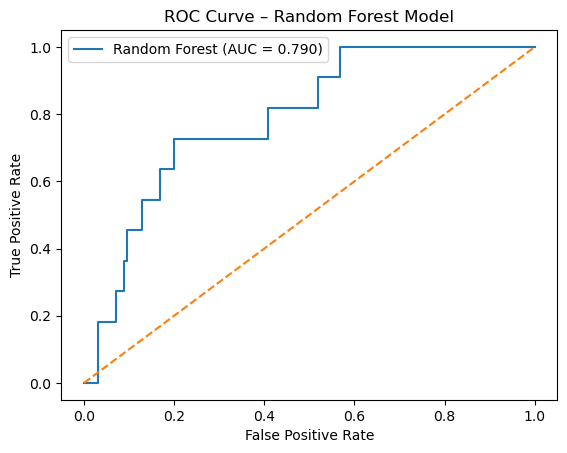

In [44]:
# ROC Curve
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

rf_fpr, rf_tpr, thresholds = roc_curve(y1_test, rf_prob)

plt.plot(rf_fpr, rf_tpr, label="Random Forest (AUC = %.3f)" % rf_auc)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Random Forest Model")
plt.legend()

plt.show()

Decision Tree

In [45]:
X2 = df[['w_points_per_race',
        'final_rank',
        'w_pole_position',
        'dnf_rate',
        'age']]

y2 = df['f1_progression']

In [46]:
# Spliting the data into Train-Test
from sklearn.model_selection import train_test_split

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2,
    test_size=0.3,
    random_state=42,
    stratify=y2
)

In [47]:
# Creating the Decision Tree Model
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X2_train, y2_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [48]:
dt_pred = dt_model.predict(X2_test)
dt_prob = dt_model.predict_proba(X2_test)[:,1]

In [49]:
# Accuracy Testing
from sklearn.metrics import accuracy_score
dt_accuracy=accuracy_score(y2_test, dt_pred)
dt_accuracy

0.875

In [50]:
# ROC-AUC Score
from sklearn.metrics import roc_auc_score
dt_auc=roc_auc_score(y2_test, dt_prob)
dt_auc

np.float64(0.5676363636363636)

In [51]:
rf_pred = rf_model.predict(X1_test)

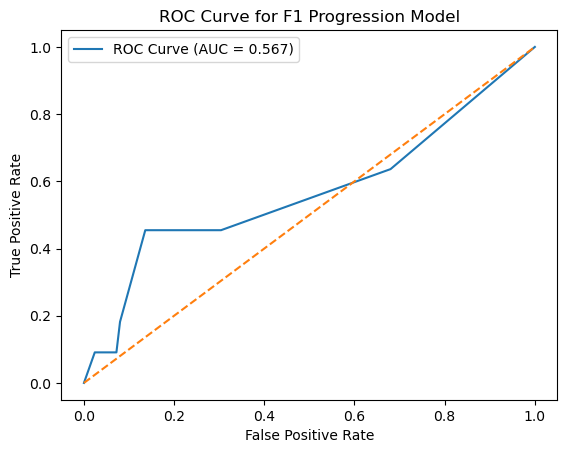

In [52]:
# ROC Curve
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr2, tpr2, thresholds2 = roc_curve(y2_test, dt_prob)

plt.figure()
plt.plot(fpr2, tpr2, label='ROC Curve (AUC = 0.567)')
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for F1 Progression Model")
plt.legend()
plt.show()

In [53]:
from sklearn.metrics import recall_score
log_recall = recall_score(y_test, y_pred)
rf_recall = recall_score(y1_test, rf_pred)
dt_recall = recall_score(y2_test, dt_pred)

In [54]:
# Comparing the Accuracy, ROC-AUC Score in a tabulation
import pandas as pd

comparison_table = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Decision Tree"],
    "Accuracy": [log_accuracy, rf_accuracy, dt_accuracy],
    "ROC-AUC": [log_auc, rf_auc, dt_auc],
    "Recall (F1 drivers)": [log_recall, rf_recall, dt_recall]
})

comparison_table

,Model,Accuracy,ROC-AUC,Recall (F1 drivers)
0,Logistic Regression,0.919118,0.897455,0.090909
1,Random Forest,0.900586,0.789818,0.090909
2,Decision Tree,0.875000,0.567636,0.090909


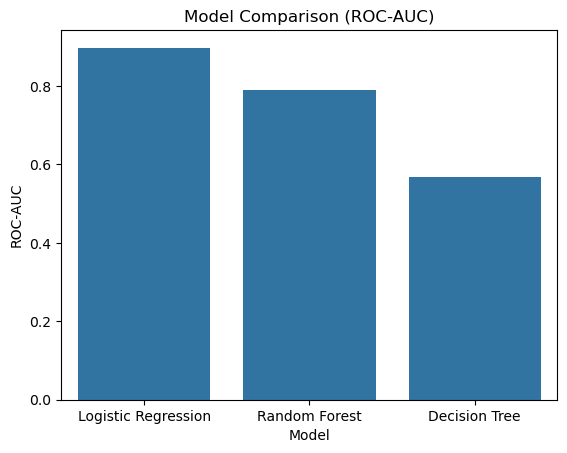

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="Model", y="ROC-AUC", data=comparison_table)

plt.title("Model Comparison (ROC-AUC)")
plt.show()

Phase 7

In [56]:
# Predict Probability for All Observations
df['predicted_probability'] = model.predict_proba(
    scaler.transform(X)
)[:,1]

In [57]:
# Calculate Predicted Probabilities
best_season = df.loc[
    df.groupby('driver_name')['predicted_probability'].idxmax()
]

In [58]:
# Find Each Driver’s Best Season
driver_ranking = best_season.sort_values(
    by='predicted_probability',
    ascending=False
)

In [59]:
# Rank Drivers
driver_ranking[['driver_name',
                'season',
                'series',
                'predicted_probability']].head(15)

,driver_name,season,series,predicted_probability
416,R. Câmara,2025,F3,0.902916
191,J. Doohan,2022,F2,0.621246
260,O. Bearman,2023,F2,0.618581
317,P. Aron,2024,F2,0.602756
216,Z. Maloney,2022,F3,0.458949
122,O. Piastri,2021,F2,0.458838
286,G. Minì,2023,F3,0.421224
151,D. Hauger,2021,F3,0.421102
63,Y. Tsunoda,2020,F2,0.419552
62,C. Ilott,2020,F2,0.418280


In [60]:
# Filter Out F1 Drivers
future_drivers = driver_ranking[
    driver_ranking['f1_progression'] == 0
]

In [61]:
# Re-Rank Them
future_drivers = future_drivers.sort_values(
    by='predicted_probability',
    ascending=False
)

In [62]:
future_drivers[['driver_name',
                   'season',
                   'predicted_probability']].head(15)

,driver_name,season,predicted_probability
416,R. Câmara,2025,0.902916
317,P. Aron,2024,0.602756
216,Z. Maloney,2022,0.458949
286,G. Minì,2023,0.421224
151,D. Hauger,2021,0.421102
62,C. Ilott,2020,0.418280
90,F. Vesti,2020,0.400300
259,V. Martins,2023,0.391673
126,T. Pourchaire,2021,0.390272
284,J. Martí,2023,0.382745


In [63]:
# Adding Seasonal weight
df['w_points_per_race'] = df['points_per_race'] * df['season_weight']
df['w_pole_position'] = df['pole_position'] * df['season_weight']

In [64]:
df.columns

Index(['s.no', 'driver_name', 'season', 'series', 'total_points', 'wins',
       'podiums', 'final_rank', 'age', 'f1_progression', 'f1_entry_year',
       'pole_position', 'total_races', 'dnfs', 'points_per_race', 'win_rate',
       'podium_rate', 'dnf_rate', 'season_weight', 'w_points_per_race',
       'w_pole_position', 'predicted_probability'],
      dtype='object')

In [65]:
index_vars = df[['w_points_per_race',
                 'final_rank',
                 'w_pole_position',
                 'dnf_rate',
                 'age']]

In [66]:
# Standardize Variables
from sklearn.preprocessing import StandardScaler
scaler_index = StandardScaler()
index_vars = df[['w_points_per_race',
                 'final_rank',
                 'w_pole_position',
                 'dnf_rate',
                 'age']]
scaled_index = scaler_index.fit_transform(index_vars)

In [67]:
import pandas as pd

scaled_df = pd.DataFrame(
    scaled_index,
    columns=index_vars.columns
)

In [68]:
# Calculate Suitability Index
df['driver_suitability_index'] = (
      0.30 * scaled_df['w_points_per_race']
    - 0.30 * scaled_df['final_rank']
    + 0.20 * scaled_df['w_pole_position']
    - 0.10 * scaled_df['dnf_rate']
    - 0.10 * scaled_df['age']
)

In [69]:
df[['driver_name','driver_suitability_index']].head()

,driver_name,driver_suitability_index
0,N. de Vries,0.955921
1,N. Latifi,0.453044
2,L. Ghiotto,0.433213
3,S. Sette Câmara,0.567432
4,J. Aitken,0.231984


In [70]:
# Remove F1 Drivers
future_drivers = df[df['f1_progression'] == 0]

In [71]:
# Rank Them by Suitability
future_ranking = future_drivers.sort_values(
    by='driver_suitability_index',
    ascending=False
)

In [72]:
# Display Top Candidates
future_ranking[['driver_name',
                'season',
                'driver_suitability_index']].head(15)

,driver_name,season,driver_suitability_index
416,R. Câmara,2025,4.245779
380,L. Fornaroli,2025,2.245364
346,L. Fornaroli,2024,2.185403
381,J. Crawford,2025,2.056422
317,P. Aron,2024,2.055619
417,N. Tsolov,2025,2.027333
348,L. Browning,2024,1.801662
382,R. Verschoor,2025,1.743626
186,F. Drugovich,2022,1.727089
255,T. Pourchaire,2023,1.605103


In [73]:
final_table = df[['driver_name',
                  'season',
                  'predicted_probability',
                  'driver_suitability_index']]

In [74]:
final_table = final_table[df['f1_progression'] == 0]

In [75]:
final_table = final_table.sort_values(
    by='predicted_probability',
    ascending=False
)

In [76]:
final_table.head(10)

,driver_name,season,predicted_probability,driver_suitability_index
416,R. Câmara,2025,0.902916,4.245779
317,P. Aron,2024,0.602756,2.055619
216,Z. Maloney,2022,0.458949,1.171131
286,G. Minì,2023,0.421224,1.149743
151,D. Hauger,2021,0.421102,1.415028
62,C. Ilott,2020,0.418280,1.036344
90,F. Vesti,2020,0.400300,0.623346
259,V. Martins,2023,0.391673,1.392192
126,T. Pourchaire,2021,0.390272,0.626482
284,J. Martí,2023,0.382745,1.347780


In [77]:
team_selection = final_table.head(2)
team_selection

,driver_name,season,predicted_probability,driver_suitability_index
416,R. Câmara,2025,0.902916,4.245779
317,P. Aron,2024,0.602756,2.055619
